# **Week2 복습과제**

**1. [ANN]**

**2. [CNN]**

- 데이터는 Week 1 과 같이 MNIST (0-9 숫자 분류) 데이터셋입니다.
- 이때, 우리의 복습과제에서는 0-4 숫자 분류를 위한 데이터 샘플만 사용할 예정입니다
- 아래 코드를 실행시켜 주세요

In [1]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, Subset
import random

# Tensor 변환을 위함
transform = transforms.Compose([
    transforms.ToTensor()
])

# MNIST 데이터셋 불러오기
train_dataset = MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = MNIST(root='./data', train=False, transform=transform, download=True)

# 무작위로 샘플 인덱스 선택
train_indices = [i for i, label in enumerate(train_dataset.targets) if label in [0, 1, 2, 3, 4]]
test_indices = [i for i, label in enumerate(test_dataset.targets) if label in [0, 1, 2, 3, 4]]

# Subset을 사용하여 샘플링된 데이터셋 생성
train_subset = Subset(train_dataset, train_indices)
test_subset = Subset(test_dataset, test_indices)


# DataLoader 생성
batch_size = 64  # 배치 크기는 64로 설정 (batch_size를 다르게 실행해보셔도 좋습니다)
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 36.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.03MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.81MB/s]


In [2]:
# 데이터셋 크기 확인을 위해 해당 셀을 실행시켜 주세요
print(f"Train dataset size: {len(train_subset)}")
print(f"Test dataset size: {len(test_subset)}")

Train dataset size: 30596
Test dataset size: 5139


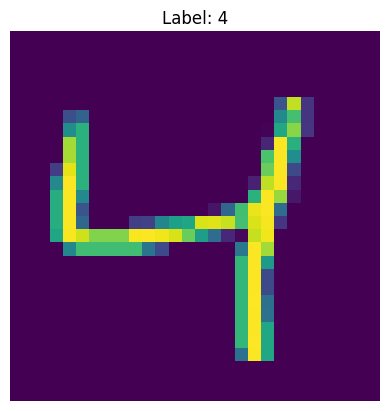

In [3]:
# 데이터셋 중 하나의 이미지를 시각화해보기
import matplotlib.pyplot as plt
import numpy as np

# 데이터셋에서 하나의 샘플 가져오기
image, label = train_subset[1]

# 텐서를 NumPy 배열로 변환
image = image.numpy().squeeze()

# 이미지 출력
plt.imshow(image)  # 이미지 표시
plt.title(f"Label: {label}")  # 레이블 표시
plt.axis("off")  # 축 없애기
plt.show()

<a id="1"></a> <br>
## **1. ANN**

**인공 신경망 (ANN)**

>  로지스틱 회귀는 분류 문제에서 성능이 좋지만, 데이터의 비선형성이 증가하면 모델의 정확도가 감소합니다.

>  따라서, hidden lyaer 에 더 많은 비선형 함수를 추가시켜 모델의 복잡도를 증가시켜 봅시다. 😀

↪ **3개의 hidden layer를 쌓고 다양한 활성화 함수 ReLU, Tanh, ELU 사용해봅시다**


In [4]:
# 필요한 라이브러리 임포트
import torch
import torch.nn as nn

#### **ANN 모델 생성**

In [5]:
# ANN Model
class ANNModel(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super(ANNModel, self).__init__()

        # Linear function 1: input_dim --> hidden_dim  (입력 차원에서 숨겨진 계층으로)
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        # Non-linearity 1 (ReLU 활성화 함수)
        self.relu1 = nn.ReLU()

        # Linear function 2: hidden_dim --> hidden_dim  (숨겨진 계층을 한 번 더 통과)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 2 (Tanh 활성화 함수 사용)
        self.tanh2 = nn.Tanh()

        # Linear function 3: hidden_dim --> hidden_dim  (추가 숨겨진 계층)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 3 (ELU 활성화 함수)
        self.elu3 = nn.ELU()

        # Linear function 4: hidden_dim --> output_dim  (마지막 출력층)
        self.fc4 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Linear function 1
        out = self.fc1(x)
        # Non-linearity 1
        out = self.relu1(out)

        # Linear function 2
        out = self.fc2(out)
        # Non-linearity 2
        out = self.tanh2(out)

        # Linear function 3
        out = self.fc3(out)
        # Non-linearity 3
        out = self.elu3(out)

        # Linear function 4
        out = self.fc4(out)  # 마지막 출력층
        return out

In [6]:
# ANN 객체 생성
input_dim = 28 * 28  # 이미지 크기 (28x28)
hidden_dim = 150  # 하이퍼파라미터 (150으로 설정)
output_dim = 5  # 출력 클래스 개수 (0~4)


model = ANNModel(input_dim,hidden_dim,output_dim)
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss() # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
learning_rate = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

#### **ANN 모델 학습**

In [ ]:
# ANN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트

# 전체 학습
for epoch in range(10):

    # 배치 단위 학습
    for i, (images, labels) in enumerate(train_loader):

        # 데이터를 모델 입력 형태로 변환 (2D 텐서로 펼치기)
        train = images.view(-1, 28 * 28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
        labels = labels  # 텐서 형태 유지

        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        # 모델을 이용해 예측값(outputs) 계산
        outputs = model(train)

        # 손실 계산
        # cross entropy loss를 사용해 예측값과 실제값 비교
        loss = loss_ftn(outputs, labels)

        # Backward propagation - 손실에 대한 기울기 계산
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            # 정확도 계산을 위한 변수 초기화
            correct = 0
            total = 0


            # 모델이 테스트 데이터셋에서 얼마나 잘 예측하는지 확인
            for images, labels in test_loader:

                test = images.view(-1, 28 * 28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
                # Forward
                # 예측값 계산
                outputs = model(test)

                # 예측값 중 가장 높은 값을 선택
                predicted = torch.max(outputs.data, 1)[1]

                # 총 샘플 개수
                total += len(labels)

                # 올바르게 예측한 개수
                correct += (predicted == labels).sum()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if count % 500 == 0:
            # 손실 및 정확도 출력
            print('Iteration: {}  Loss: {}  Accuracy: {} %'.format(count, loss.data, accuracy))


Iteration: 500  Loss: 0.12671028077602386  Accuracy: 96.26386260986328 %
Iteration: 1000  Loss: 0.05100254341959953  Accuracy: 97.10060119628906 %
Iteration: 1500  Loss: 0.12740591168403625  Accuracy: 97.6259994506836 %
Iteration: 2000  Loss: 0.04554085060954094  Accuracy: 97.85950469970703 %
Iteration: 2500  Loss: 0.02648785337805748  Accuracy: 97.93733978271484 %
Iteration: 3000  Loss: 0.09030584245920181  Accuracy: 98.093017578125 %
Iteration: 3500  Loss: 0.0792650431394577  Accuracy: 98.1319351196289 %
Iteration: 4000  Loss: 0.032511793076992035  Accuracy: 98.40435791015625 %
Iteration: 4500  Loss: 0.0465775728225708  Accuracy: 98.50165557861328 %


#### **ANN 학습 결과**

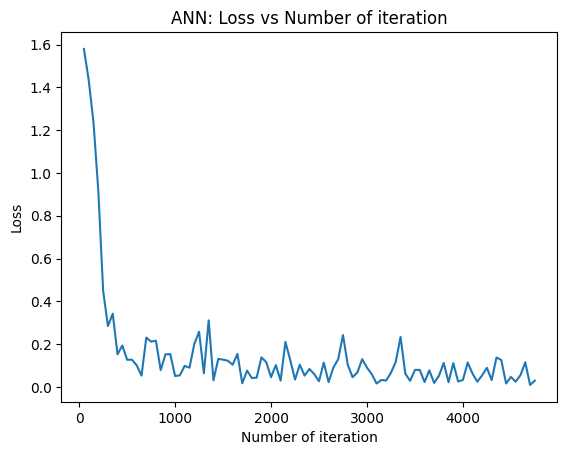

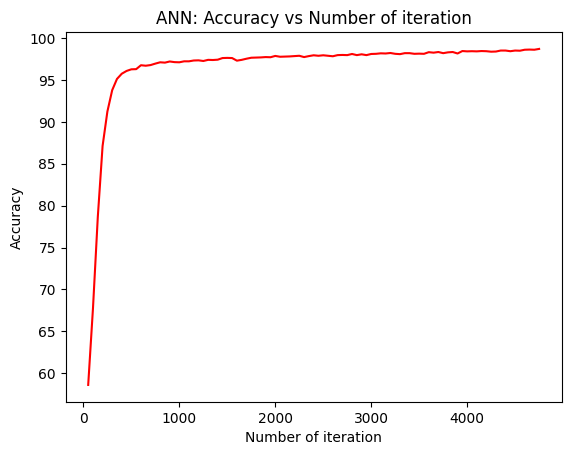

In [ ]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("ANN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("ANN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 시각화된 모델의 학습 결과를 해석해주세요.** 🤗



---
**[해석]**
-
- 학습이 진행될수록 loss는 감소하고 accuracy는 증가하였다.
점차 증가하는 accuracy와 다르게 loss는 계속 감소하지 않고 일부 구간에서는 증가하기도 했지만 전체적으로는 감소하는 경향을 보였다.
 학습이 진행되면서 모델이 데이터를 점점 더 잘 학습하여 분류 성능이 향상되었음을 알 수 있다.



#### **ANN 최적의 하이퍼파라미터 찾기**

1️⃣ **실험 1: Hidden Dimension 최적값 찾기**
- hidden_dim 값을 50-200 사이 값들로 설정하고 모델을 학습
- 각 hidden_dim 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교




2️⃣ **실험 2: Learning Rate 최적값 찾기**

- learning_rate 값을 0.1-0.005 사이 값들로 설정하고 모델을 학습
- 각 learning_rate 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교



**⚠ 이때 epoch 값은 자유롭게 해주셔도 됩니다! **

In [ ]:
# 실험 1 hidden_dims=[50-200 사이 값들] 로 학습
hidden_dims = [50, 100, 150, 200]
loss_results = []
accuracy_results = []

for hidden_dim in hidden_dims:
  #hidden_dim을 바꿀 때마다 새로운 모델 생성
  model = ANNModel(input_dim, hidden_dim, output_dim)
  loss_ftn = nn.CrossEntropyLoss()
  optimizer = torch.optim.SGD(model.parameters(), lr = 0.02)

  count = 0
  loss_list = []
  accuracy_list = []
  iteration_list = []

  for epoch in range(5):
    for i, (images, labels) in enumerate(train_loader):

      train = images.view(-1, 28 * 28)
      optimizer.zero_grad()

      outputs = model(train)
      loss = loss_ftn(outputs, labels)

      loss.backward()
      optimizer.step()

      count += 1
      if count % 50 == 0:
        correct = 0
        total = 0

        for images, labels in test_loader:

          test = images.view(-1, 28*28)

          outputs = model(test)
          predicted = torch.max(outputs.data, 1)[1]

          total += len(labels)
          correct += (predicted == labels).sum()

        accuracy = 100 * correct / float(total)

        loss_list.append(loss.item())
        iteration_list.append(count)
        accuracy_list.append(accuracy)

      if count % 500 == 0:
        print('Hidden Dim: {} | Iteration: {} | Loss: {} | Accuracy: {} %'.format(
            hidden_dim, count, loss.data, accuracy
            ))

  loss_results.append(loss_list)
  accuracy_results.append(accuracy_list)

Hidden Dim: 50 | Iteration: 500 | Loss: 0.14010003209114075 | Accuracy: 96.2833251953125 %
Hidden Dim: 50 | Iteration: 1000 | Loss: 0.09986791759729385 | Accuracy: 97.17843627929688 %
Hidden Dim: 50 | Iteration: 1500 | Loss: 0.05913485959172249 | Accuracy: 97.37303161621094 %
Hidden Dim: 50 | Iteration: 2000 | Loss: 0.09430444985628128 | Accuracy: 97.7038345336914 %
Hidden Dim: 100 | Iteration: 500 | Loss: 0.14255815744400024 | Accuracy: 96.20549011230469 %
Hidden Dim: 100 | Iteration: 1000 | Loss: 0.09243155270814896 | Accuracy: 97.08114624023438 %
Hidden Dim: 100 | Iteration: 1500 | Loss: 0.07021403312683105 | Accuracy: 97.56761932373047 %
Hidden Dim: 100 | Iteration: 2000 | Loss: 0.18932576477527618 | Accuracy: 97.76220703125 %
Hidden Dim: 150 | Iteration: 500 | Loss: 0.15850405395030975 | Accuracy: 96.40007781982422 %
Hidden Dim: 150 | Iteration: 1000 | Loss: 0.26265183091163635 | Accuracy: 97.08114624023438 %
Hidden Dim: 150 | Iteration: 1500 | Loss: 0.10235509276390076 | Accuracy

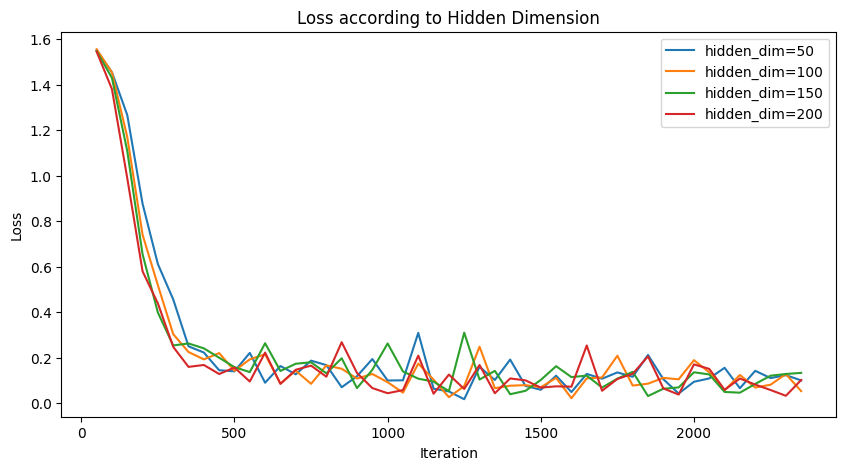

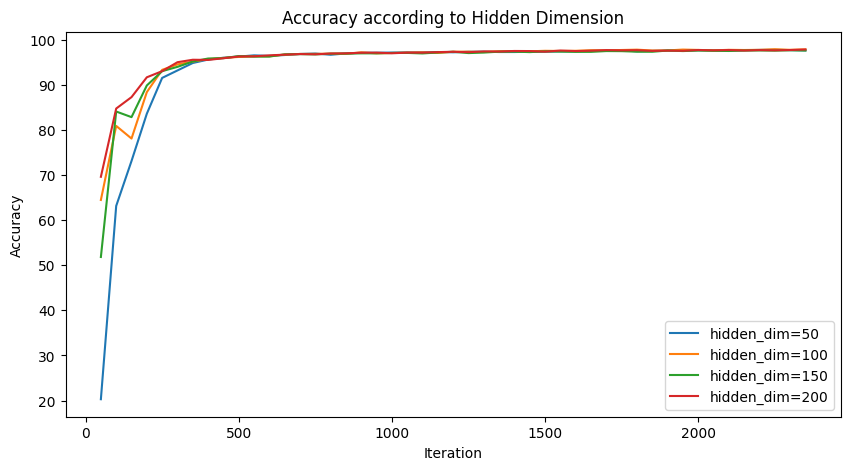

In [ ]:
# 실험 1 모델 학습 결과 시각화
plt.figure(figsize = (10, 5))

for i, hidden_dim in enumerate(hidden_dims):
  plt.plot(iteration_list, loss_results[i],
           label = f'hidden_dim={hidden_dim}')

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss according to Hidden Dimension')
plt.legend()
plt.show()

plt.figure(figsize = (10, 5))

for i, hidden_dim in enumerate(hidden_dims):
  plt.plot(iteration_list, accuracy_results[i],
           label = f'hidden_dim={hidden_dim}')

plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Accuracy according to Hidden Dimension')
plt.legend()
plt.show()

**해당 셀의 마크 다운을 풀고 hidden dimension 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**
-
- Hidden dimension이 증가할수록 모델이 학습할 수 있는 특징의 표현력이 증가하여 Loss가 감소하고 accuracy가 증가하였다.
- Hidden dimension이 50일 때 accuracy가 97.70%, 100에서는 97.76%, 150에서는 97.63%, 200에서는 97.74%로 나타났다. 따라서 Hidden dimension이 크다고 해서 무조건 성능이 계속 향상되는게 아닌 것을 확인할 수 있다.
- 100~200에서는 성능 차이가 크지 않아 dimension 증가에 따른 효과가 크지 않다는 것을 알 수 있다.
- 하지만 dimension이 너무 작으면 모델의 표현력이 부족할 수 있고 너무 크면 학습 시간이 오래 걸려 모두 고려하여 적절한 hidden dimension 값을 설정해야 한다.

In [ ]:
# 실험 2 learning_rates=[0.1-0.005 사이 값들] 로 학습
learning_rates = [0.1, 0.05, 0.01, 0.005]

loss_results = []
accuracy_results = []

hidden_dim = 150

for learning_rate in learning_rates:

    # learning rate를 바꿀 때마다 새로운 모델 생성
    model = ANNModel(input_dim, hidden_dim, output_dim)
    loss_ftn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

    count = 0
    loss_list = []
    accuracy_list = []
    iteration_list = []

    for epoch in range(5):

        for i, (images, labels) in enumerate(train_loader):

            train = images.view(-1, 28 * 28)

            optimizer.zero_grad()

            outputs = model(train)
            loss = loss_ftn(outputs, labels)

            loss.backward()
            optimizer.step()

            count += 1

            if count % 50 == 0:

                correct = 0
                total = 0

                for images, labels in test_loader:

                    test = images.view(-1, 28 * 28)

                    outputs = model(test)
                    predicted = torch.max(outputs.data, 1)[1]

                    total += len(labels)
                    correct += (predicted == labels).sum()

                accuracy = 100 * correct / float(total)

                loss_list.append(loss.item())
                iteration_list.append(count)
                accuracy_list.append(accuracy)

            if count % 500 == 0:
                print('Learning Rate: {} | Iteration: {} | Loss: {} | Accuracy: {} %'.format(
                    learning_rate, count, loss.data, accuracy
                ))

    loss_results.append(loss_list)
    accuracy_results.append(accuracy_list)

Learning Rate: 0.1 | Iteration: 500 | Loss: 0.05359930172562599 | Accuracy: 97.74275207519531 %
Learning Rate: 0.1 | Iteration: 1000 | Loss: 0.0943746268749237 | Accuracy: 98.42382049560547 %
Learning Rate: 0.1 | Iteration: 1500 | Loss: 0.11042624711990356 | Accuracy: 98.89083099365234 %
Learning Rate: 0.1 | Iteration: 2000 | Loss: 0.04848678410053253 | Accuracy: 99.1048812866211 %
Learning Rate: 0.05 | Iteration: 500 | Loss: 0.10861311852931976 | Accuracy: 97.56761932373047 %
Learning Rate: 0.05 | Iteration: 1000 | Loss: 0.11103832721710205 | Accuracy: 97.93733978271484 %
Learning Rate: 0.05 | Iteration: 1500 | Loss: 0.17866893112659454 | Accuracy: 98.24868774414062 %
Learning Rate: 0.05 | Iteration: 2000 | Loss: 0.11222762614488602 | Accuracy: 98.618408203125 %
Learning Rate: 0.01 | Iteration: 500 | Loss: 0.37786155939102173 | Accuracy: 93.03366088867188 %
Learning Rate: 0.01 | Iteration: 1000 | Loss: 0.17012226581573486 | Accuracy: 96.16657257080078 %
Learning Rate: 0.01 | Iteration

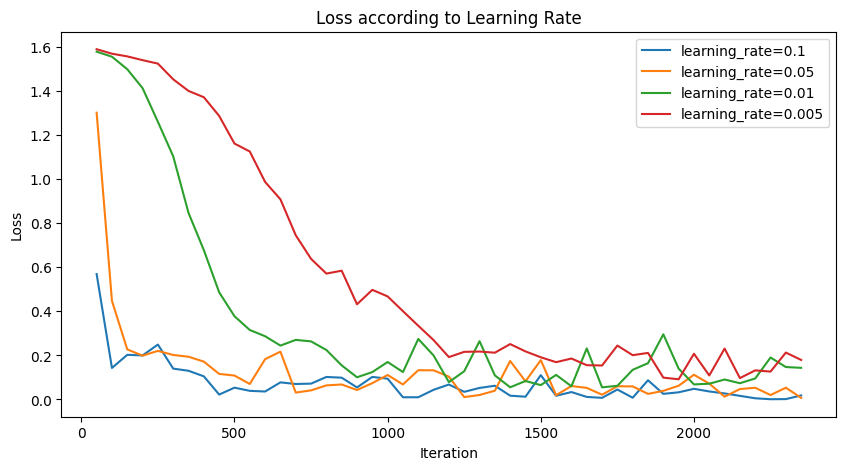

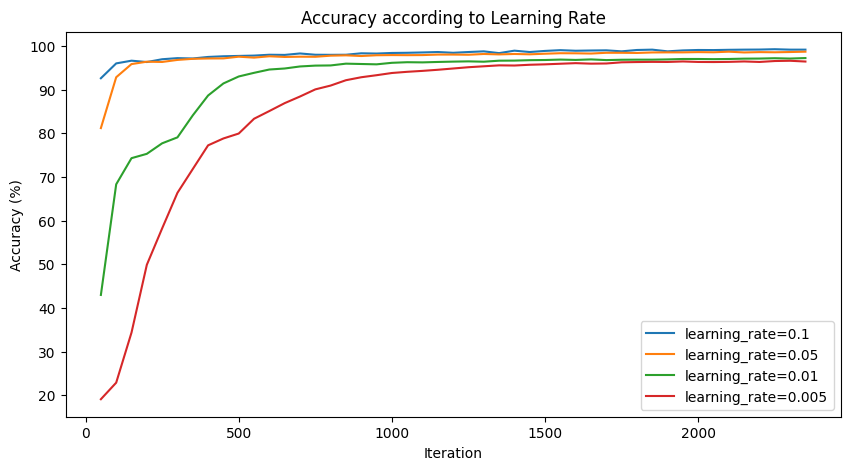

In [ ]:
# 실험 2 모델 학습 결과 시각화

plt.figure(figsize=(10, 5))

for i, learning_rate in enumerate(learning_rates):
    plt.plot(iteration_list, loss_results[i],
             label=f'learning_rate={learning_rate}')

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss according to Learning Rate')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))

for i, learning_rate in enumerate(learning_rates):
    plt.plot(iteration_list, accuracy_results[i],
             label=f'learning_rate={learning_rate}')

plt.xlabel('Iteration')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy according to Learning Rate')
plt.legend()
plt.show()

**해당 셀의 마크 다운을 풀고 learning rate 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**
-
- Learning rate는 학습 과정에서 가중치를 업데이트하는 크기에 영향을 준다.
실험 결과 learning rate가 0.005, 0.01일 때보다 0.05, 0.1일 때 같은 iteration에서 더 높은 accuracy를 보였다. 특히 0.1에서는 2000 iteration에서 99.10%로 높은 accuracy를 보였다. 따라서 learning rate가 너무 작으면 학습이 느려지고, 적절한 값으로 증가시키면 빠르게 성능을 향상시킬 수 있음을 확인하였다.

<a id="1"></a> <br>
## **2. CNN**
> CNN은 이미지 분류에 적합한 모델로, kernel을 이용해 feature map을 생성합니다

**↪ 2개의 합성곱 계층을 쌓고, 활성화 함수로 ReLU를 사용하며,Max Pooling layer를 적용해봅시다.**

#### **CNN 모델 생성**

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim

# CNN Model 정의
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # 합성곱 계층 1 (Conv Layer 1)
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.relu1 = nn.ReLU()  # 활성화 함수 (ReLU)

        # Max Pooling 1
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)  # kernel size를 2로 설정

        # 합성곱 계층 2 (Conv Layer 2)
        self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0)
        self.relu2 = nn.ReLU()  # 활성화 함수 (ReLU)

        # Max Pooling 2
        self.maxpool2 = nn.MaxPool2d(kernel_size=2) # kernel size를 2로 설정

        # Fully Connected Layer
        self.fc1 = nn.Linear(32*4*4, 10)  # 입력 차원 및 출력 차원 지정

    def forward(self, x):
        # 합성곱 계층 1 + 활성화 함수
        out = self.cnn1(x)
        out = self.relu1(out)

        # Max Pooling 1
        out = self.maxpool1(out)

        # 합성곱 계층 2 + 활성화 함수
        out = self.cnn2(out)
        out = self.relu2(out)

        # Max Pooling 2
        out = self.maxpool2(out)

        # feature map을 flatten하게
        out = out.view(out.size(0), -1)

        # 완전 연결 계층
        out = self.fc1(out)

        return out


In [10]:
# CNN 객체 생성
model = CNNModel()
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss()  # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
optimizer = optim.SGD(model.parameters(), lr=0.02)  # 학습률을 자유롭게 설정해주세요

#### **CNN 모델 학습**

In [11]:
# CNN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트
num_epochs = 20  # 학습할 에포크 수 설정 -> 자유롭게 설정해주셔도 됩니다

for epoch in range(num_epochs):
    running_loss = 0.0  # 에포크별 손실 초기화

    for images, labels in train_loader:
        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        outputs = model(images)

        # 손실 계산
        loss = loss_ftn(outputs, labels)

        # Backward
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        # 손실 누적
        running_loss += loss.item()
        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            correct = 0
            total = 0

            with torch.no_grad():  # 평가
                for images, labels in test_loader:
                    # 모델 예측 수행
                    outputs = model(images)

                    # 가장 확률이 높은 클래스 선택
                    predicted = torch.max(outputs.data, 1)[1]

                    # 총 샘플 수 및 올바른 예측 개수 누적
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

    # 매 에포크마다 평균 손실 출력
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader)}")

Epoch 1, Loss: 0.32134850753280714
Epoch 2, Loss: 0.10233212843350677
Epoch 3, Loss: 0.07774247380949573
Epoch 4, Loss: 0.0631055460391189
Epoch 5, Loss: 0.05319888879581975
Epoch 6, Loss: 0.04548092397067906
Epoch 7, Loss: 0.03947408472707676
Epoch 8, Loss: 0.03643605584663432
Epoch 9, Loss: 0.03264500083275906
Epoch 10, Loss: 0.03018322929308316
Epoch 11, Loss: 0.028373186177348558
Epoch 12, Loss: 0.026561349991510674
Epoch 13, Loss: 0.02523286203880034
Epoch 14, Loss: 0.023143842067795035
Epoch 15, Loss: 0.021894288746327054
Epoch 16, Loss: 0.021102744423310876
Epoch 17, Loss: 0.020413505519708202
Epoch 18, Loss: 0.01912060307143431
Epoch 19, Loss: 0.018451168942036758
Epoch 20, Loss: 0.017625655270947654


#### **CNN 학습 결과**

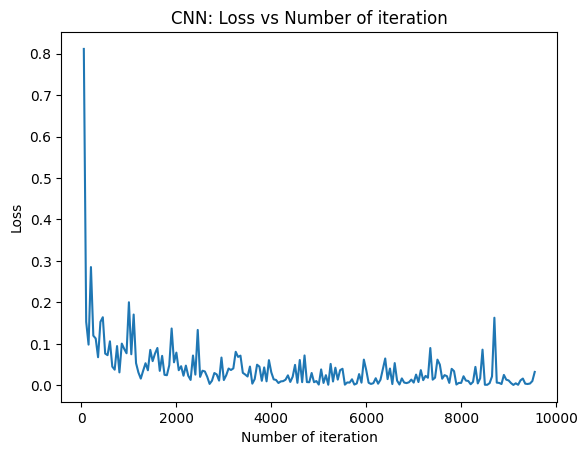

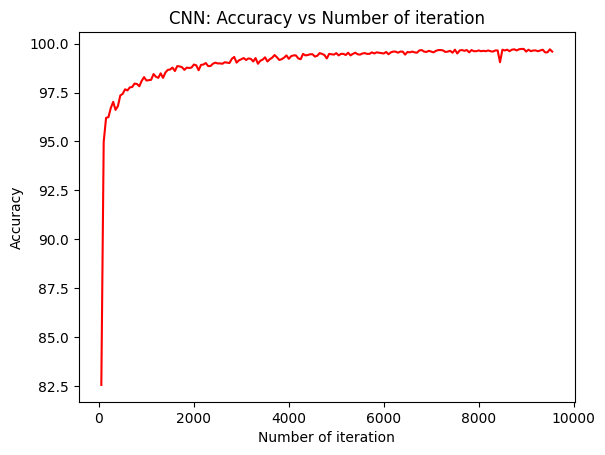

In [12]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("CNN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("CNN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 MNIST 데이터셋에서 ANN, CNN의 학습 결과 비교와 함께 두 모델에 대해 각각 짧게 소개해주세요.** 🤗



---
**[답변]**
-
- ANN은 입력 데이터를 여러 개의 완전 연결층을 통해 분류하는 신경망이다. 이미지의 픽셀 간 공간적인 위치 관계보다는 각 픽셀의 값을 이용하여 학습한다. 학습 결과, ANN은 반복 횟수가 증가할수록 loss가 감소하고 accuracy가 증가하였다. 4,500 iteration에서는 loss가 0.0466, accuracy가 98.50%로 측정되었다. ANN이 비교적 단순한 이미지 분류 문제에서는 높은 분류 성능을 얻을 수 있음을 확인하였다.
- CNN은 이미지와 같은 공간적 구조를 가진 데이터를 처리하는데 적합한 신경망이다. 합성곱층을 이용하여 이미지의 지역적인 특징을 추출하고 추출된 특징을 펼쳐 완전 연결층을 통해 최종적으로 숫자를 분류한다. 학습 결과, epoch가 증가할수록 loss가 감소하였다. 이는 학습이 진행되면서 모델이 MNIST 이미지의 특징을 점차 효과적으로 학습하고 있음을 보여준다.
- ANN과 CNN 모두 반복 횟수가 증가할수록 loss가 감소하고 accuracy가 증가했지만 CNN은 ANN보다 초반부터 더 빠르게 높은 정확도에 도달하는 모습을 보였다. 또한 같은 반복 구간에서 CNN의 accuracy가 ANN보다 높게 유지되었으며 loss 역시 CNN이 전반적으로 더 낮은 수준으로 나타났다. 이는 CNN이 완전 연결층만 사용하는 ANN과 달리 합성곱 연산을 통해 이미지의 공간적 특징을 활용하기 때문에 MNIST의 이미지 구조를 보다 효과적으로 학습했기 때문이라고 볼 수 있다.
